# Tasca S10.01. Analítica de dades en Pandas

**Descripció**
 
En aquesta tasca t’enfrontaràs a un exercici de neteja i analítica de dades.

Tenim un dataset provinent d’una enquesta als nostres treballadors i treballadors, i hem de garantir que les dades es processes correctament, tant en format com en llegibilitat.

## Importar llibreries

In [1]:
import pandas as pd
from pandas.api.types import is_numeric_dtype, is_string_dtype, is_datetime64_any_dtype
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, date

## Llegir documents

In [2]:
FILE_SPRINT10 = './data/raw/sprint10.xlsx'
FILE_DISTANCIES = './data/raw/matriu_distancies.xlsx'

## Nivell 1

### 1.

Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

- Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.
- Mostra les primeres 10 files.
- Addicionalment, fes un print on comprovi que el DNI només té valors únics.

**Importar dataframe**

In [3]:
df_sprint10 = pd.read_excel(FILE_SPRINT10, header=3, index_col=0) # comprovat prèviament que la columna 0 tenia valors únics per a cada fila (carregant el df sense index_col i nunique, amb 1000).
df_sprint10.head(2)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A


In [4]:
df_sprint10_raw = df_sprint10.copy()

In [5]:
df_sprint10.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Nom                1000 non-null   str    
 1   Cognoms            1000 non-null   str    
 2   DNI                1000 non-null   str    
 3   País d'origen      1000 non-null   str    
 4   Ciutat             1000 non-null   str    
 5   Dia de Naixement   1000 non-null   int64  
 6   Mes de Naixement   1000 non-null   int64  
 7   Any de Naixement   1000 non-null   int64  
 8   Gènere             1000 non-null   str    
 9   Salari mensual     1000 non-null   str    
 10  Fills              406 non-null    float64
 11  No Fills           594 non-null    float64
 12  Grup Professional  1000 non-null   str    
dtypes: float64(2), int64(3), str(8)
memory usage: 101.7 KB


Neteja de noms de columnes

In [6]:
df_sprint10.columns = df_sprint10.columns.str.lower().str.replace(' ', '_', regex = False).str.replace("d'", "", regex = False)

In [7]:
df_sprint10.columns

Index(['nom', 'cognoms', 'dni', 'país_origen', 'ciutat', 'dia_de_naixement',
       'mes_de_naixement', 'any_de_naixement', 'gènere', 'salari_mensual',
       'fills', 'no_fills', 'grup_professional'],
      dtype='str')

**Ordenar dataframe per pais i ciutat**

Netejar espais a pais_origen i ciutat

In [8]:
df_sprint10['país_origen'] = df_sprint10['país_origen'].str.strip()
df_sprint10['ciutat'] = df_sprint10['ciutat'].str.strip()

In [9]:
df_sprint10.sort_values(by=['país_origen','ciutat'], inplace=True)
df_sprint10.reset_index(drop=True, inplace=True) # si ho faig seguit dóna error perquè inplace=True no es pot encadenar perquè retorna None. Segons chatGPT cada cop menys recomanat i millor declarar primer la variable i després el reset_index.
df_sprint10.head(2)

,nom,cognoms,dni,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional
0,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B


**Primeres 10 files**

In [10]:
df_sprint10.head(10)

,nom,cognoms,dni,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional
0,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
2,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
3,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
4,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
5,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
6,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
7,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
8,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
9,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


**Comprovar DNI només té valors únics**

In [11]:
df_sprint10['dni'].is_unique #P2P Maria

True

In [12]:
files_totals = df_sprint10.shape[0]
DNI_unics = df_sprint10['dni'].nunique()

print(f'El DNI té valors únics donat que per a un total de {files_totals} files, hi ha {DNI_unics} valors únics de DNI.')

El DNI té valors únics donat que per a un total de 1000 files, hi ha 1000 valors únics de DNI.


### 2.

- Crea una columna que sigui el nom complet.
- Crea una columna si la persona és nascuda a Espanya o no.
- Posa el DNI com a índex del DataFrame (noms de files).
- Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.
- Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).

Mostra tots els canvis que has realitzat en una sola taula.

**Creació columna amb nom complet**

In [13]:
df_sprint10.insert(2, "nom_complet", df_sprint10['nom'] + ' ' + df_sprint10['cognoms'])
df_sprint10.head(2)

,nom,cognoms,nom_complet,dni,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional
0,Mia,Schneider Fischer,Mia Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,Laura,Schneider Fischer,Laura Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B


**Creació columna persona nascuda a Espanya**  
Primer neteja de possibles espais en blanc i comprovació de valors únics per si hi ha duplicats.

In [14]:
df_sprint10['país_origen'].unique()

<StringArray>
[  'Alemanya',  'Argentina',   'Colòmbia',    'Espanya',     'França',
     'Itàlia',     'Marroc',      'Mèxic',   'Portugal', 'Regne Unit']
Length: 10, dtype: str

In [15]:
df_sprint10['origen_espanya'] = np.where(df_sprint10['país_origen'] == 'Espanya', True, False)
df_sprint10.head(2)

,nom,cognoms,nom_complet,dni,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya
0,Mia,Schneider Fischer,Mia Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,False
1,Laura,Schneider Fischer,Laura Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,False


**DNI com a índex del DataFrame**

In [16]:
df_sprint10.set_index('dni', inplace=True)
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia_de_naixement,mes_de_naixement,any_de_naixement,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya
dni,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,False
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,False


**Substitució nom de les columnes**  
Donat que ho he transformat tot a minúscules poso els nous noms de les columnes en minúscula.

In [17]:
df_sprint10.rename(columns={"dia_de_naixement":"dia", "mes_de_naixement":"mes", "any_de_naixement":"any"}, inplace=True)
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya
dni,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,False
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,False


**Substitució H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na)**  
- Primer he comprovat els valors únics de gènere així com quants valors hi ha de cadascú i si hi ha nulls
- Després he fet la substitutció
- Finalment he comprovat  que s'hagi fet correctament amb el nombre de nulls de la columna

In [18]:
df_sprint10['gènere'].value_counts()

gènere
H     449
D     440
NC     60
A      51
Name: count, dtype: int64

In [19]:
df_sprint10['gènere'].isnull().sum()

np.int64(0)

In [20]:
df_sprint10['gènere'] = df_sprint10['gènere'].replace({'A':'Altres','D':'Dona','H':'Home','NC':np.nan})
df_sprint10['gènere'].unique()

<StringArray>
['Altres', 'Dona', 'Home', nan]
Length: 4, dtype: str

In [21]:
df_sprint10['gènere'].isnull().sum()

np.int64(60)

**Mostrar canvis en una taula**  
He creat un df on només apareixen les columnes modificades i com a comentari es pot printar el df original incloent els canvis (amb les columnes no modificades)

In [22]:
df_sprint10.loc[:,['nom_complet','origen_espanya', 'dia','mes','any','gènere']]
# P2P: solo mostrar, no crear nueva variable
# df_sprint10_canvis = df_sprint10.loc[:,['nom_complet','origen_espanya', 'dia','mes','any','gènere']]
# df_sprint10_canvis

,nom_complet,origen_espanya,dia,mes,any,gènere
dni,,,,,,
28973553Z,Mia Schneider Fischer,False,22,10,1976,Altres
37399141L,Laura Schneider Fischer,False,2,2,1958,Dona
37368317L,Lea Schneider Schneider,False,23,10,2005,Dona
21390098Z,Mia Fischer,False,11,8,1950,Dona
44060014R,Jonas Schneider,False,22,11,1985,Home
...,...,...,...,...,...,...
89577876S,Emily Taylor Jones,False,28,3,1958,Dona
57441590Y,George Brown Jones,False,27,12,1979,Home
58204038A,Olivia Brown Brown,False,28,8,1952,Altres


In [23]:
# df_sprint10

#### Altres comprovacions (**no revisar**)

In [24]:
df_sprint10['país_origen'][df_sprint10['país_origen'].str.startswith('E')].unique()

<StringArray>
['Espanya']
Length: 1, dtype: str

In [25]:
df_sprint10.loc[df_sprint10['país_origen'] == 'Espanya']

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills,no_fills,grup_professional,origen_espanya
dni,,,,,,,,,,,,,,
27724652S,Clara,Sánchez Martínez,Clara Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,1.253 €,1.0,NaN,Grup A,True
69630528M,Toni,Sánchez García,Toni Sánchez García,Espanya,Barcelona,9,8,1999,Home,1.043 €,NaN,1.0,Grup A,True
14219925Z,Toni,Martínez,Toni Martínez,Espanya,Barcelona,16,5,1964,Home,891 €,NaN,1.0,Grup A,True
40695825B,Oriol,Sánchez,Oriol Sánchez,Espanya,Barcelona,27,7,1965,Home,1.250 €,NaN,1.0,Grup A,True
74222289K,Toni,Castells Romero,Toni Castells Romero,Espanya,Barcelona,13,4,1961,Home,1.438 €,NaN,1.0,Grup B,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42807414J,Laia,Sánchez,Laia Sánchez,Espanya,València,17,7,1967,Dona,2.255 €,NaN,1.0,Grup C,True
38147748A,Núria,Martínez Ferrer,Núria Martínez Ferrer,Espanya,València,4,11,1976,Dona,1.028 €,NaN,1.0,Grup A,True
48749091Z,Oriol,Sánchez García,Oriol Sánchez García,Espanya,València,16,7,1965,Home,1.273 €,NaN,1.0,Grup A,True


### 3.

Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".  
*Donat que he posat tots els noms de columnes en minúscula, he anomenat la columna 'fills' en comptes de 'Fills'.*

Comprovar els valors únics i canvi nom columna fills per no duplicar

In [26]:
display(df_sprint10['fills'].unique())
display(df_sprint10['no_fills'].unique())

array([nan,  1.])

array([ 1., nan])

In [27]:
# P2P renombrar columna fills
df_sprint10.rename(columns={'fills':'fills_bool','no_fills':'no_fills_bool'}, inplace=True)

Crear la funció

In [28]:
def fills(row):
    if row["fills_bool"] == 1.0:
        return 'Sí'
    elif row["no_fills_bool"] == 1.0:
        return 'No'
    else:
        return np.nan

Aplicar la funció

In [29]:
df_sprint10['fills'] = df_sprint10.apply(fills, axis=1)

Comprovar resultat

In [30]:
df_sprint10['fills'].unique()

<StringArray>
['No', 'Sí']
Length: 2, dtype: str

In [31]:
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills_bool,no_fills_bool,grup_professional,origen_espanya,fills
dni,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí


### 4.

- Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
- Ordena la taula en funció del sou mig.

Preprocessament columna salari_mensual

In [32]:
df_sprint10.dtypes

nom                      str
cognoms                  str
nom_complet              str
país_origen              str
ciutat                   str
dia                    int64
mes                    int64
any                    int64
gènere                   str
salari_mensual           str
fills_bool           float64
no_fills_bool        float64
grup_professional        str
origen_espanya          bool
fills                    str
dtype: object

Creació nova columna

In [33]:
df_sprint10['salari_mensual_int'] = (
    df_sprint10['salari_mensual']
    .str.replace(r"\D", "", regex=True)
    .astype(int)
)
df_sprint10.head(2)


,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills_bool,no_fills_bool,grup_professional,origen_espanya,fills,salari_mensual_int
dni,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769


Comprovar moneda salari

In [34]:
df = df_sprint10[['salari_mensual']]
df['moneda_salari'] = df['salari_mensual'].str[-1]
print(f'Valors únics:\n{df['moneda_salari'].unique()}\n')
print(f'Valors nuls:\n {df['moneda_salari'].isnull().sum()}')


Valors únics:
<StringArray>
['€']
Length: 1, dtype: str

Valors nuls:
 0


**Agrupació per taula descriptiva ordenada per salari mitjà**  
La primera conté els paràmetres demanats i la segona més descriptius

In [35]:
df_sprint10.groupby('gènere')['salari_mensual_int'].aggregate(['mean','median','min','max']).sort_values('mean')

,mean,median,min,max
gènere,,,,
Dona,1469.443182,1361.5,665,3021
Altres,1626.588235,1545.0,703,3175
Home,1643.249443,1531.0,737,3356


In [36]:
#P2P round(2) 
df_sprint10.groupby('gènere')['salari_mensual_int'].describe().round(2).sort_values('mean')

,count,mean,std,min,25%,50%,75%,max
gènere,,,,,,,,
Dona,440.0,1469.44,542.08,665.0,1080.0,1361.5,1785.25,3021.0
Altres,51.0,1626.59,611.91,703.0,1198.0,1545.0,2018.00,3175.0
Home,449.0,1643.25,582.58,737.0,1239.0,1531.0,2027.00,3356.0


### 5.

- Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
- Afegeix-hi les mitjanes als marges de la taula.

**Taula resum salari mig per gènere i país d'origen amb mitjanes als marges de la taula**

In [37]:
crosstab = pd.crosstab(df_sprint10['gènere'],df_sprint10['país_origen'], df_sprint10['salari_mensual_int'], aggfunc='mean', margins=True, margins_name='mitjana').round(2)
crosstab

país_origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,mitjana
gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
mitjana,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


Comprovar que a França no hi ha persones de gènere Altres

In [38]:
df_sprint10['gènere'][df_sprint10['país_origen'] == 'França'].unique()

<StringArray>
['Home', 'Dona', nan]
Length: 3, dtype: str

(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

**Taula resum salari mig per gènere i país d'origen amb format condicional per valors**

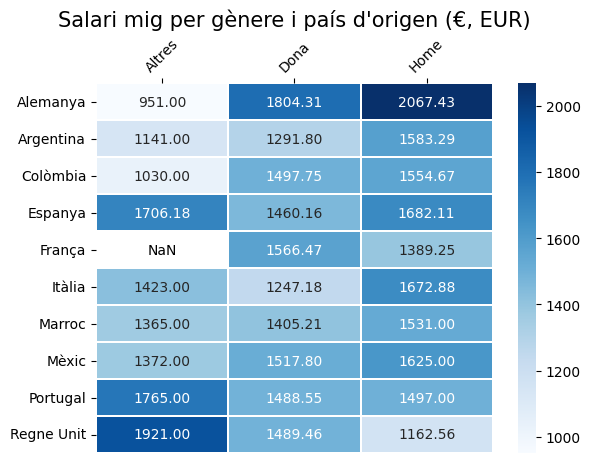

In [39]:
data = pd.crosstab(df_sprint10['país_origen'], df_sprint10['gènere'], df_sprint10['salari_mensual_int'], aggfunc='mean')

# plot heatmap

ax = sns.heatmap(data, cmap="Blues", annot = True, linewidth=0.3, fmt=".2f") #annot són valors per cel·la, fmt el nombre de decimals, linewidth la linia blanca entre cel·les

# xticks
ax.xaxis.tick_top()
plt.xticks(plt.xticks()[0], rotation=45)

# yticks
plt.yticks(plt.yticks()[0], rotation=0)

# axis labels
plt.xlabel('')
plt.ylabel('')

# annotate 'NaN', recórrer cada cel·la del heatmap (cada combinació fila-columna) i si és NaN escriure 'NaN' (ax.text)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if pd.isna(data.iloc[i, j]):
            ax.text(j + 0.5, i + 0.5, 'NaN',
                    ha='center', va='center')

#title
title = "Salari mig per gènere i país d'origen (€, EUR)"
plt.title(title, fontsize=15)
          
plt.show()

P2P: para formato condicional, ha usado **df.style.format('{:.1f}').highlight_max(color='blue')**
format es para poner solo 1 decimal

### 6.

- Crea una columna nova que sigui la data de naixement en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
- Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [40]:
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills_bool,no_fills_bool,grup_professional,origen_espanya,fills,salari_mensual_int
dni,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769


**Creació nova columna data naixement en format datetime**

In [41]:
df_sprint10['data_naixement'] = pd.to_datetime(df_sprint10['any'].astype(str) + '/' + df_sprint10['mes'].astype(str) + '/' + df_sprint10['dia'].astype(str))
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills_bool,no_fills_bool,grup_professional,origen_espanya,fills,salari_mensual_int,data_naixement
dni,,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951,1976-10-22
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769,1958-02-02


Comprovació format datetime

In [42]:
df_sprint10.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 28973553Z to 82046699J
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   nom                 1000 non-null   str           
 1   cognoms             1000 non-null   str           
 2   nom_complet         1000 non-null   str           
 3   país_origen         1000 non-null   str           
 4   ciutat              1000 non-null   str           
 5   dia                 1000 non-null   int64         
 6   mes                 1000 non-null   int64         
 7   any                 1000 non-null   int64         
 8   gènere              940 non-null    str           
 9   salari_mensual      1000 non-null   str           
 10  fills_bool          406 non-null    float64       
 11  no_fills_bool       594 non-null    float64       
 12  grup_professional   1000 non-null   str           
 13  origen_espanya      1000 non-null   bool          


In [43]:
df_sprint10.loc[['28973553Z'], 'data_naixement'].dt.month

dni
28973553Z    10
Name: data_naixement, dtype: int32

**Funció càlcul edat data d'avui**

In [44]:
def calcul_edat(data_naixement: datetime) -> int:
    """
    Calcula l'edat actual a partir de la data de naixement.

    L'edat es calcula tenint en compte si l'aniversari d'aquest any
    ja ha passat o no.

    Args:
        data_naixement (datetime): Data de naixement de la persona.

    Returns:
        int: Edat actual en anys.
    """
    data_actual = date.today()
    edat_actual = data_actual.year - data_naixement.year - ((data_actual.month, data_actual.day) < (data_naixement.month, data_naixement.day))
    # Comparació de tuples: primer compara mesos i si són iguals compara dies. El resultat és True (1) o False(0). SI no ha passat l'aniversari, resta un any.

    return edat_actual

**Creació columna edat_actual a partir de la funció**

In [45]:
df_sprint10['edat_actual'] = df_sprint10['data_naixement'].apply(calcul_edat)
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills_bool,no_fills_bool,grup_professional,origen_espanya,fills,salari_mensual_int,data_naixement,edat_actual
dni,,,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951,1976-10-22,49
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769,1958-02-02,68


## Nivell 2

### 1.

- Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.
- Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

```
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})
```
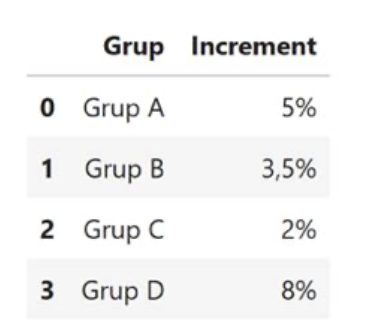

Creació dataframe

In [46]:
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})
df_increment

,Grup,Increment
0,Grup A,5%
1,Grup B,"3,5%"
2,Grup C,2%
3,Grup D,8%


Neteja valors dataframe

In [47]:
df_increment['Increment'] = df_increment['Increment'].str.replace('%', '').str.replace(',', '.').astype(float)
df_increment

,Grup,Increment
0,Grup A,5.0
1,Grup B,3.5
2,Grup C,2.0
3,Grup D,8.0


In [48]:
df_increment.rename(columns={'Grup':'grup_professional','Increment':'increment'}, inplace=True) # per a poder fer el merge amb només un nom ID

**Adjuntar la columna increment al df anterior (df_sprint10)**

In [49]:
df_sprint10 = pd.merge(df_sprint10,df_increment, on='grup_professional')
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills_bool,no_fills_bool,grup_professional,origen_espanya,fills,salari_mensual_int,data_naixement,edat_actual,increment
0,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,951,1976-10-22,49,5.0
1,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1769,1958-02-02,68,3.5


**Actualització columna salari (salari_mensual_int) en funció dels percentatges que s'adjunten**

In [50]:
df_sprint10['salari_mensual_int'] = df_sprint10['salari_mensual_int'] + (df_sprint10['salari_mensual_int'] * (df_sprint10['increment']/100)).round(2)
df_sprint10.head(2)

,nom,cognoms,nom_complet,país_origen,ciutat,dia,mes,any,gènere,salari_mensual,fills_bool,no_fills_bool,grup_professional,origen_espanya,fills,salari_mensual_int,data_naixement,edat_actual,increment
0,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,False,No,998.55,1976-10-22,49,5.0
1,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,False,Sí,1830.92,1958-02-02,68,3.5


### 2.

Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [51]:
grups = df_sprint10['grup_professional'].unique().tolist()

Crear funció guardar df a csv

In [52]:
def guardar_csv(df: pd.DataFrame, nom: str) -> str:
    timestamp = datetime.now().strftime("%Y%m%d%H%M")
    path = f'./data/processed/dades_{nom}_{timestamp}.xlsx'
    df.to_csv(path, index=False)
    return path

**Exportar dades group professionals amb un bucle**

In [53]:
for grup in grups:
    df = df_sprint10[df_sprint10['grup_professional'] == grup]
    nom_grup = grup.replace(' ','')
    path = guardar_csv(df,nom_grup)
    print(path)

./data/processed/dades_GrupA_202603241151.xlsx
./data/processed/dades_GrupB_202603241151.xlsx
./data/processed/dades_GrupD_202603241151.xlsx
./data/processed/dades_GrupC_202603241151.xlsx


**Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.**

Creació df amb descriptius

In [54]:
df_grups_descriptius = df_sprint10.groupby('grup_professional').agg(
    salari_mitja=('salari_mensual_int', lambda x: round(x.mean(), 2)),
    edat_mediana=('edat_actual', 'median')
).reset_index()
display(df_grups_descriptius)

,grup_professional,salari_mitja,edat_mediana
0,Grup A,1213.32,51.0
1,Grup B,1724.55,47.5
2,Grup C,2289.19,52.0
3,Grup D,3100.82,43.0


In [55]:
path = guardar_csv(df_grups_descriptius, 'grups_descriptius')
print(path)

./data/processed/dades_grups_descriptius_202603241151.xlsx


## Nivell 3

El nivell 3 d’aquest sprint és totalment diferent a d’altres sprints que has fet fins ara, ja que són exercicis més abstractes que requereixen barallar-s’hi bastant. No continuen amb el mateix dataset dels nivells anteriors, sinó que et plantegen dues situacions noves totalment diferents entre elles.

### 1.

Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

- un histograma/boxplot si la variable és numèrica
- unes barres dels valors més freqüents si és categòrica
- unes barres dels anys més freqüents si la dada està en format data.

La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, *iris, penguins* o *titanic*.

**Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.**

**Creació de la funció**

In [56]:
def dtypes_graph(df: pd.DataFrame) -> None:
    """
    Genera i guarda un gràfic per a cada columna del DataFrame segons el seu tipus de dada.

    Les columnes numèriques es representen amb histogrames, les de tipus datetime amb gràfics de barres per any,
    i les columnes categòriques o de text amb gràfics de recompte.
    """

    sns.set_theme(style="whitegrid", palette="pastel")

    for col in df.columns:
        
        plt.figure(figsize=(6,4))
        ax = plt.gca()
        
        if is_numeric_dtype(df[col]):
            sns.histplot(df[col].dropna())
            plt.title(f'Numeric variable: {col}')

        elif is_datetime64_any_dtype(df[col]):
            if df[col].dt.year.nunique(dropna=True) > 15:
                df[col].dt.year.dropna().value_counts().sort_index().tail(15).plot(kind='bar')
                for container in ax.containers:
                    ax.bar_label(container, fontsize=8)
                plt.title(f'Datetime variable: {col} (last 15 years)')
            else:
                df[col].dt.year.dropna().value_counts().sort_index().plot(kind='bar')
                for container in ax.containers:
                    ax.bar_label(container, fontsize=8)
                plt.title(f'Datetime variable: {col}')

        elif (
        isinstance(df[col].dtype, pd.CategoricalDtype) or
        is_string_dtype(df[col])
        ):
            if df[col].nunique(dropna=True) > 10:
                df[col].dropna().value_counts().head(10).plot(kind='bar') # ya sale ordenado
                for container in ax.containers:
                    ax.bar_label(container, fontsize=8)
                plt.title(f'Categorical variable: {col} (top 10)')
            else:
                df[col].dropna().value_counts().plot(kind='bar')
                for container in ax.containers:
                    ax.bar_label(container, fontsize=8)
                plt.title(f'Categorical variable: {col}')

        current_date = datetime.now().strftime("%Y%m%d%H%M")
    
        plt.xlabel('')
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        plt.savefig(f'./images/{col}_{current_date}.png', transparent = True)
        plt.show()

**Mostrar resultat**  
Fet amb els datasets penguins (variables numèriques i categòriques) i flights (variable datetime i numèrica).  
*Nota*: Els dos datasets s'han preprocessat (neteja d'espais, duplicats i canvis de dtype).

Càrrega df_penguins

In [57]:
df_penguins = sns.load_dataset('penguins')
df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [58]:
df_penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


Neteja df_penguins (duplicats, espais en blanc)

In [59]:
df_penguins_raw = df_penguins.copy()
df_penguins = df_penguins.drop_duplicates()

for col in df_penguins.columns.tolist():
    if is_string_dtype(df_penguins[col]):
        df_penguins[col] = df_penguins[col].str.strip()

**Aplicar funció**

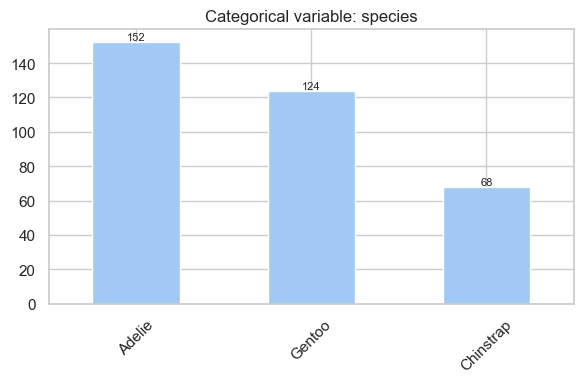

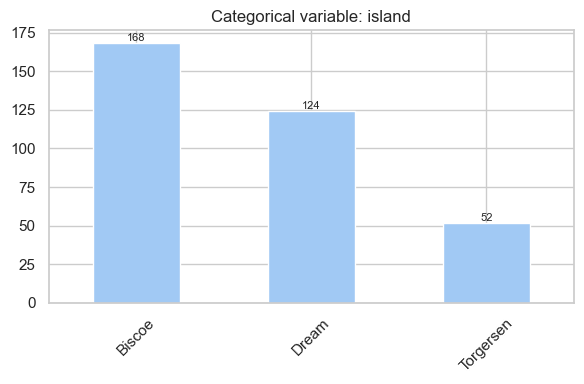

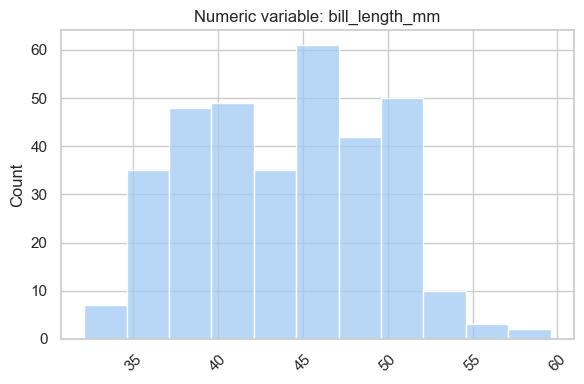

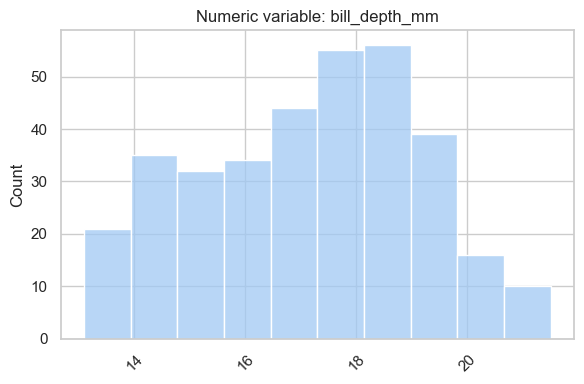

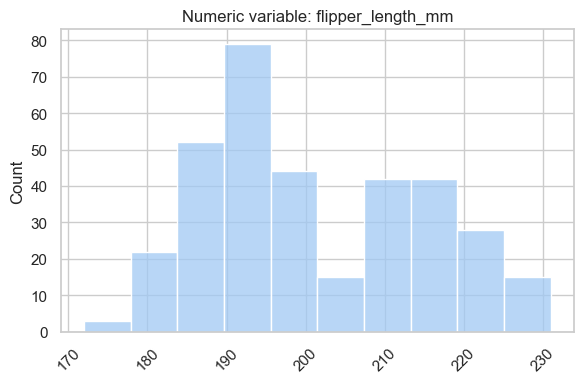

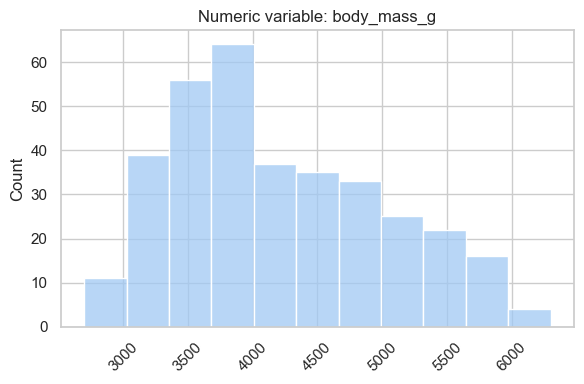

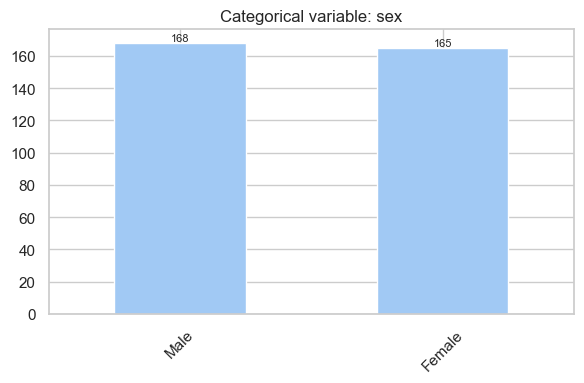

In [60]:
dtypes_graph(df_penguins)

Càrrega df_flights

In [61]:
df_flights = sns.load_dataset("flights")
df_flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [62]:
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


Preprocessament df_flights (datetime dtype)

In [63]:
df_flights['year_month'] = pd.to_datetime(
    df_flights['year'].astype(str) + '-' + df_flights['month'].astype(str),
    format='%Y-%b'
)

In [64]:
df_flights = df_flights.loc[0:,'passengers':'year_month']
df_flights.head(2)

,passengers,year_month
0,112,1949-01-01
1,118,1949-02-01


In [65]:
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   passengers  144 non-null    int64         
 1   year_month  144 non-null    datetime64[us]
dtypes: datetime64[us](1), int64(1)
memory usage: 2.4 KB


**Aplicar funció**

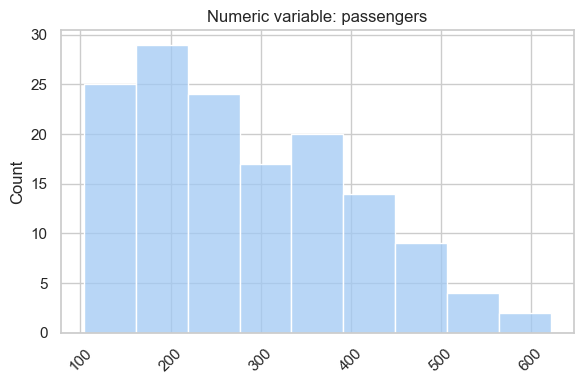

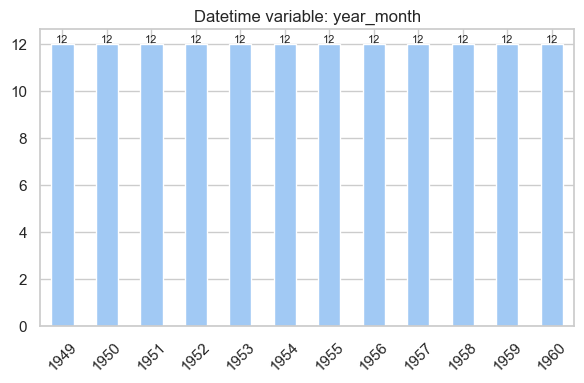

In [66]:
dtypes_graph(df_flights)

#### Codis extra, procediment fet amb select_dtype i llista/diccionari i plot/subplot (**no revisar**)

In [67]:
df_penguins = sns.load_dataset('penguins')
df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [68]:
df_penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [69]:
df_penguins.shape

(344, 7)

In [70]:
df_penguins.drop_duplicates(inplace=True)

In [71]:
df_penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [72]:
def get_column_names(data):
        """ This function will be used to extract the column names for numerical and categorical variables
        info from the dataset
        input: dataframe containing all variables
        output: num_vars-> list of numerical columns
                cat_vars -> list of categorical columns"""

        num_var = data.select_dtypes(include=['number']).columns.tolist()
        print()
        print('Numerical variables are:\n', num_var)
        print('-------------------------------------------------')

        categ_var = data.select_dtypes(include=['category', 'object','str']).columns.tolist()
        print('Categorical variables are:\n', categ_var)
        print('-------------------------------------------------') 
        date_var = data.select_dtypes(include='datetime').columns.tolist()
        print('Datetime variables are:\n', date_var)
        print('-------------------------------------------------') 
        return num_var, categ_var, date_var

In [73]:
num_var, categ_var, date_var = get_column_names(df_penguins)


Numerical variables are:
 ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
-------------------------------------------------
Categorical variables are:
 ['species', 'island', 'sex']
-------------------------------------------------
Datetime variables are:
 []
-------------------------------------------------


In [74]:
df_penguins.loc[0:,'bill_length_mm':'body_mass_g']

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0
...,...,...,...,...
339,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


dictionary

In [75]:
num_var_dict = {'bill_length_mm':1, 'bill_depth_mm':2, 'flipper_length_mm':3, 'body_mass_g':4}

In [76]:
type(num_var_dict)

dict

In [77]:
def get_column_names_dict(data):
        
        
        num_var_dict = {}
        categ_var_dict = {}
        datetime_var_dict = {}

        count_num = 1
        count_categ = 1
        count_date = 1

        num_var = data.select_dtypes(include=['number']).columns.tolist()
        categ_var = data.select_dtypes(include=['category', 'object','str'], exclude = ['datetime']).columns.tolist()
        date_var = data.select_dtypes(include='datetime').columns.tolist()

        for column in num_var:
                num_var_dict[column] = count_num
                count_num += 1

        for column in categ_var:
                categ_var_dict[column] = count_categ
                count_categ += 1
        
        for column in date_var:
                datetime_var_dict[column] = count_date
                count_date += 1

        print('Categorical variables are:\n', num_var_dict)
        print('-------------------------------------------------') 
        print('Categorical variables are:\n', categ_var_dict)
        print('-------------------------------------------------') 
        print('Datetime variables are:\n', datetime_var_dict)
        print('-------------------------------------------------') 
        return num_var_dict, categ_var_dict, datetime_var_dict

In [78]:
num_var_dict, categ_var_dict, datetime_var_dict = get_column_names_dict(df_penguins)

Categorical variables are:
 {'bill_length_mm': 1, 'bill_depth_mm': 2, 'flipper_length_mm': 3, 'body_mass_g': 4}
-------------------------------------------------
Categorical variables are:
 {'species': 1, 'island': 2, 'sex': 3}
-------------------------------------------------
Datetime variables are:
 {}
-------------------------------------------------


In [79]:
len(num_var_dict)

4

subplots

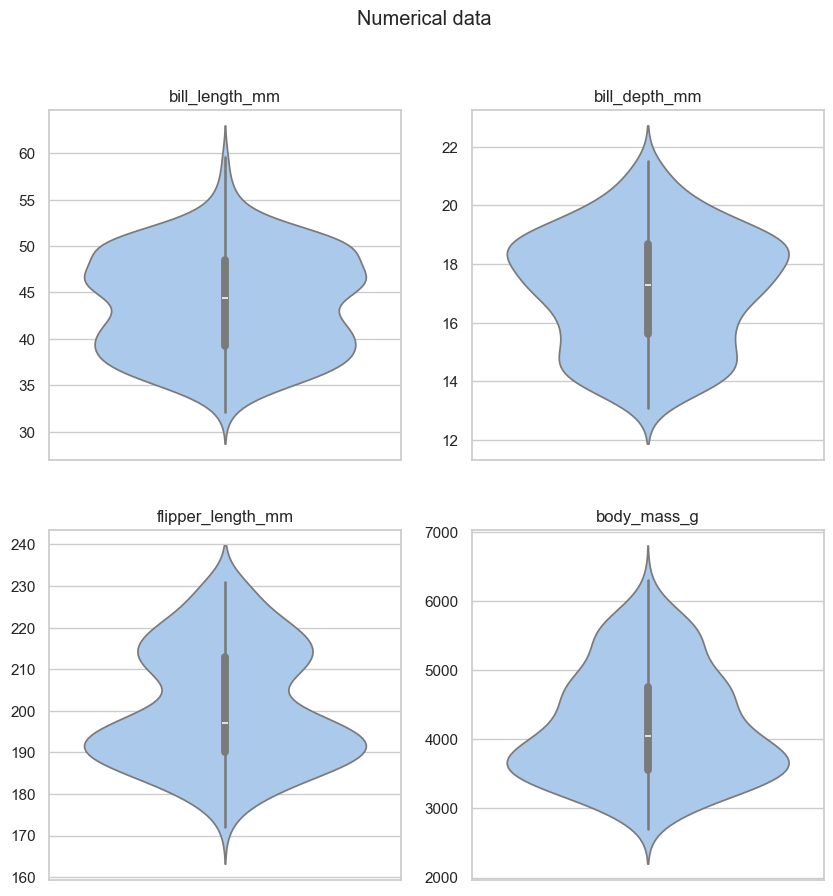

In [80]:
plt.figure(figsize=(10,10))

for x,y in num_var_dict.items():
    data = df_penguins[x]
    rows_subplot = int(len(num_var_dict) / 2)
    plt.subplot(rows_subplot,2,y)
    sns.violinplot(data=data)
    plt.ylabel('')
    plt.title(x)
plt.suptitle('Numerical data')
plt.show()

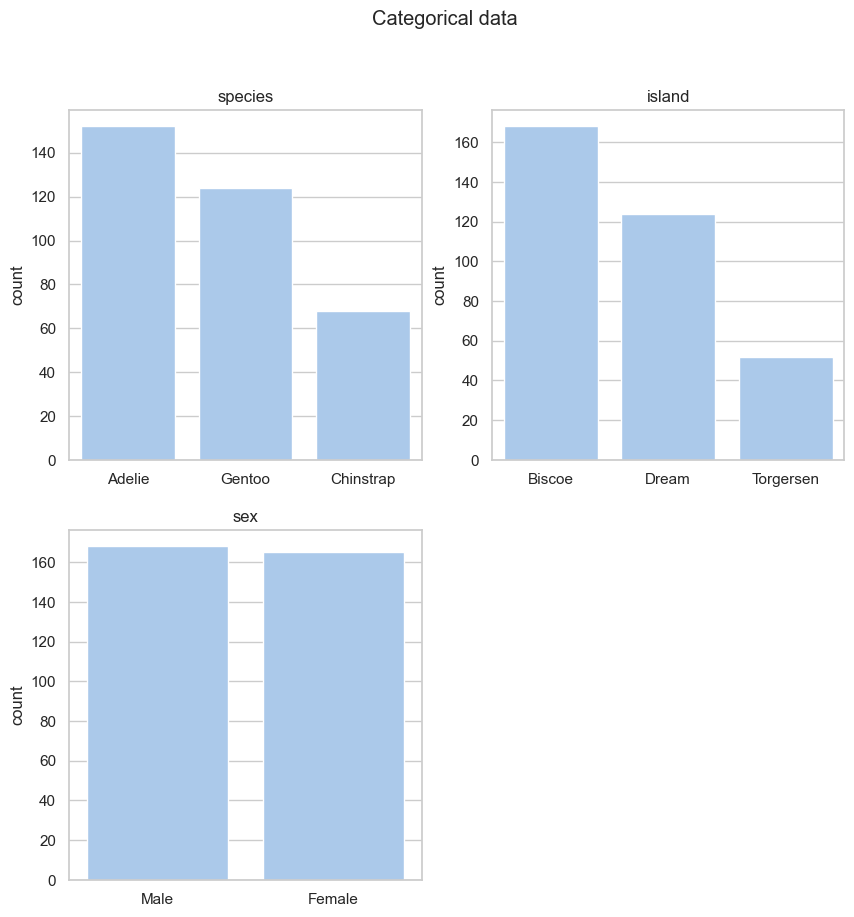

In [81]:
plt.figure(figsize=(10,10))

for x,y in categ_var_dict.items():
    data = df_penguins[x].value_counts()
    rows_subplot = int(np.ceil(len(categ_var_dict) / 2))
    plt.subplot(rows_subplot,2,y)
    sns.barplot(data=data)
    plt.xlabel('')
    plt.title(x)
plt.suptitle('Categorical data')
plt.show()

- https://www.youtube.com/watch?v=4DnWYK88-E4
- https://www.geeksforgeeks.org/python/how-to-create-subplots-in-seaborn/
- https://dev.to/thalesbruno/subplotting-with-matplotlib-and-seaborn-5ei8
- https://www.w3schools.com/Python/matplotlib_labels.asp

*Floor and Ceiling numbers*
- https://note.nkmk.me/en/python-pandas-round-decimal/#the-round-method-rounds-half-to-even-bankers-rounding

In [82]:
df1 = sns.load_dataset('flights')
df1

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [83]:
df_flights = sns.load_dataset("flights")
df_flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [84]:
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [85]:
df_flights['year_month'] = pd.to_datetime(
    df_flights['year'].astype(str) + '-' + df_flights['month'].astype(str)
)
df_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    category      
 2   passengers  144 non-null    int64         
 3   year_month  144 non-null    datetime64[us]
dtypes: category(1), datetime64[us](1), int64(2)
memory usage: 4.0 KB


/var/folders/z0/sx07zxxs0419_1m36l2hr_xr0000gp/T/ipykernel_2754/2864010656.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_flights['year_month'] = pd.to_datetime(


In [86]:
df_flights.describe().T

,count,mean,min,25%,50%,75%,max,std
year,144.0,1954.5,1949.0,1951.75,1954.5,1957.25,1960.0,3.464102
passengers,144.0,280.298611,104.0,180.0,265.5,360.5,622.0,119.966317
year_month,144,1954-12-16 05:00:00,1949-01-01 00:00:00,1951-12-24 06:00:00,1954-12-16 12:00:00,1957-12-08 18:00:00,1960-12-01 00:00:00,NaN


In [87]:
df_flights['year'].unique().tolist()

[1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960]

In [88]:
num_var, categ_var, date_var = get_column_names(df_flights)


Numerical variables are:
 ['year', 'passengers']
-------------------------------------------------
Categorical variables are:
 ['month']
-------------------------------------------------
Datetime variables are:
 ['year_month']
-------------------------------------------------


year_month


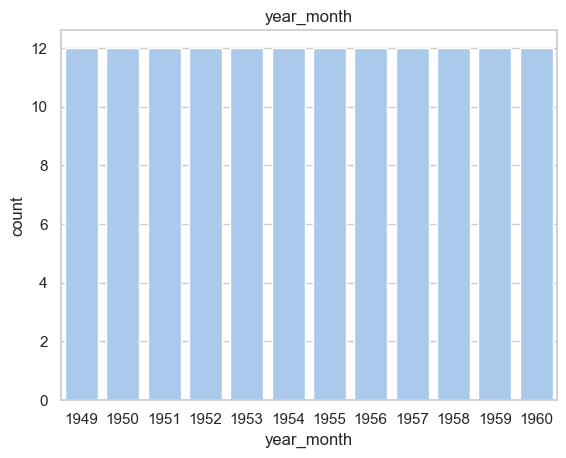

In [89]:
for i in date_var:
    print(i)
    data = df_flights[i].dt.year.value_counts()
    # plt.figure(figsize=(7,7))
    sns.barplot(data=data)
    plt.title(i)
    plt.show()

1 plot each graph

for i in num_var:
    print(i)
    data = df_penguins[i]
    # plt.figure(figsize=(7,7))
    sns.violinplot(data=data)
    plt.title(i)
    plt.show()

for i in categ_var:
    print(i)
    data = df_penguins[i].value_counts()
    # plt.figure(figsize=(7,7))
    sns.barplot(data=data)
    plt.xlabel('')
    plt.title(i)
    plt.show()

### 2.
 Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: [Mejores Rutas](https://espana.mejoresrutas.com/tabla-de-distancias/es/)

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

**No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.**

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara

Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

Càrrega dataset

In [90]:
df_distancies_index = pd.read_excel(FILE_DISTANCIES, index_col=0)
df_distancies_index

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Palma,Las Palmas de Gran Canaria,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,206.0,2175.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,260.0,1874.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,791.0,1355.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,377.0,2001.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,695.0,1406.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,372.0,1723.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Palma,206.0,260.0,791.0,377.0,695.0,372.0,NaN,2093.0,621.0,303.0,671.0,664.0,1000.0,820.0,204.0
Las Palmas de Gran Canaria,2175.0,1874.0,1355.0,2001.0,1406.0,1723.0,2093.0,NaN,2022.0,1792.0,1470.0,1790.0,1682.0,1925.0,2168.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,621.0,2022.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,303.0,1792.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0


Comprovació valors índex

In [91]:
df_distancies_index.index.is_unique

True

In [92]:
df_distancies_index.index.unique()

Index(['Barcelona', 'Valencia', 'Sevilla', 'Zaragoza', 'Málaga', 'Murcia',
       'Palma', 'Las Palmas de Gran Canaria', 'Bilbao', 'Alicante', 'Córdoba',
       'Valladolid', 'Vigo', 'Gijón', 'Hospitalet de Llobregat'],
      dtype='str')

Neteja valors especificats (index i columnes)

In [93]:
df_distancies_index.drop(index=['Palma', 'Las Palmas de Gran Canaria'], inplace=True)
df_distancies_index.index.unique()

Index(['Barcelona', 'Valencia', 'Sevilla', 'Zaragoza', 'Málaga', 'Murcia',
       'Bilbao', 'Alicante', 'Córdoba', 'Valladolid', 'Vigo', 'Gijón',
       'Hospitalet de Llobregat'],
      dtype='str')

In [94]:
df_distancies_index.drop(columns=['Palma', 'Las Palmas de Gran Canaria'], inplace=True)

**Definició de la funció**

In [95]:
def distancies(matriu, origen: str) -> tuple[list[str], int]:
    """
    Calcula un recorregut entre ciutats sempre seleccionant la ciutat més propera des de l'actual.

    Args:
        matriu: DataFrame amb les distàncies entre ciutats.
        origen (str): Ciutat d'inici del recorregut.

    Returns:
        tuple[list[str], int]:
            - Llista amb l'ordre de les ciutats visitades.
            - Distància total recorreguda.
    """
    viatges = {}
    city = origen
    df = matriu.copy()

    while len(df.index) > 1:
        df.drop(index=city, inplace=True)
        minvalueIndexLabel = df[city].idxmin()
        min_value = int(df[city].min())
        
        viatges[minvalueIndexLabel] = min_value

        city = minvalueIndexLabel


    trajecte = list(viatges.keys())
    distancia = sum(viatges.values())

    # print(f'El trajecte més curt des de la ciutat de {origen} és:\n {trajecte}.\n Recorreràs una distància total de {distancia} km.')
    
    return trajecte, distancia

In [96]:
trajecte, distancia = distancies(df_distancies_index,'Córdoba')

In [97]:
print(f'El trajecte més curt des de la ciutat de Córdoba és:\n{trajecte}.\nRecorreràs una distància total de {distancia} km.')

El trajecte més curt des de la ciutat de Córdoba és:
['Sevilla', 'Málaga', 'Murcia', 'Alicante', 'Valencia', 'Zaragoza', 'Bilbao', 'Gijón', 'Valladolid', 'Vigo', 'Hospitalet de Llobregat', 'Barcelona'].
Recorreràs una distància total de 2981 km.


P2P: cuando pasas dictionary a list puede que no mantenga el orden? Puede que no esté garantizado.  
Comprovat i:
⚠️ Important tenir en compte
✔️ Python ≥ 3.7 → ordre garantit oficialment
⚠️ Python 3.6 → funciona però era “implementació”, no estàndard
❌ Python < 3.6 → NO es garanteix l’ordre

(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat?

In [98]:
# Canviat després de P2P
ciutat = {}

for col in df_distancies_index:
    trajecte, distancia = distancies(df_distancies_index,col)
    ciutat[col] = distancia

min_val = min(ciutat.values())
ciutat_curta = min(ciutat, key=ciutat.get)

print(f"\n--> La ciutat des d'on la ruta seria més curta segons l'algoritme plantejat és {ciutat_curta}.\nRecorreràs un total de {min_val} km per a visitar totes les principals ciutats espanyoles.")


--> La ciutat des d'on la ruta seria més curta segons l'algoritme plantejat és Barcelona.
Recorreràs un total de 2778 km per a visitar totes les principals ciutats espanyoles.


#### Altres opcions de resoldre

In [99]:
# 2a opció canviat al P2P per iteració de diccionari en comptes d'ordenar i després seleccionar primer
ciutat = {}

print('Viatges possibles:')
for col in df_distancies_index:
    trajecte, distancia = distancies(df_distancies_index,col)
    ciutat[col] = distancia
    print(f'Origen: {col} -> distància total: {distancia}')

min_val = min(ciutat.values())

for x, y in ciutat.items():
  if y == min_val:
     ciutat_curta = x
     km_curt = y
     print(ciutat_curta,km_curt)

print(f"\n--> La ciutat des d'on la ruta seria més curta segons l'algoritme plantejat és {ciutat_curta}.\nRecorreràs un total de {km_curt} km per a visitar totes les principals ciutats espanyoles.")

Viatges possibles:
Origen: Barcelona -> distància total: 2778
Origen: Valencia -> distància total: 3200
Origen: Sevilla -> distància total: 2956
Origen: Zaragoza -> distància total: 3415
Origen: Málaga -> distància total: 3066
Origen: Murcia -> distància total: 3082
Origen: Bilbao -> distància total: 3431
Origen: Alicante -> distància total: 3134
Origen: Córdoba -> distància total: 2981
Origen: Valladolid -> distància total: 3357
Origen: Vigo -> distància total: 2873
Origen: Gijón -> distància total: 3439
Origen: Hospitalet de Llobregat -> distància total: 2784
Barcelona 2778

--> La ciutat des d'on la ruta seria més curta segons l'algoritme plantejat és Barcelona.
Recorreràs un total de 2778 km per a visitar totes les principals ciutats espanyoles.


In [100]:
# Opció que tenia abans del P2P
ciutat = {}

print('Viatges possibles:')
for col in df_distancies_index:
    trajecte, distancia = distancies(df_distancies_index,col)
    ciutat[col] = distancia
    print(f'Origen: {col} -> distància total: {distancia}')

asc = {k: v for k, v in sorted(ciutat.items(), key=lambda item: item[1])}
ciutat_ruta_curta = list(asc)[0]
km = ciutat[ciutat_ruta_curta]

print(f"\n--> La ciutat des d'on la ruta seria més curta segons l'algoritme plantejat és {ciutat_ruta_curta}, amb un total de {km} km.")

Viatges possibles:
Origen: Barcelona -> distància total: 2778
Origen: Valencia -> distància total: 3200
Origen: Sevilla -> distància total: 2956
Origen: Zaragoza -> distància total: 3415
Origen: Málaga -> distància total: 3066
Origen: Murcia -> distància total: 3082
Origen: Bilbao -> distància total: 3431
Origen: Alicante -> distància total: 3134
Origen: Córdoba -> distància total: 2981
Origen: Valladolid -> distància total: 3357
Origen: Vigo -> distància total: 2873
Origen: Gijón -> distància total: 3439
Origen: Hospitalet de Llobregat -> distància total: 2784

--> La ciutat des d'on la ruta seria més curta segons l'algoritme plantejat és Barcelona, amb un total de 2778 km.


#### Solució chatGPT

## Pàgines web


- [Sorting a Pandas DataFrame by a Single Column](https://medium.com/@whyamit404/sorting-a-pandas-dataframe-by-a-single-column-7c035cc64289)
- [How to Sort Pandas DataFrame?](https://www.geeksforgeeks.org/pandas/how-to-sort-pandas-dataframe/)
- [Python | Pandas DataFrame.set_index()](https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-set_index/)

*Heatmap Seaborn, matplotlib*:
- https://tutegomeze.medium.com/conceptos-b%C3%A1sicos-de-heatmap-con-seaborn-ea074be662ea
- https://www.geeksforgeeks.org/python/how-to-change-seaborn-legends-font-size-location-and-color/
- https://seaborn.pydata.org/generated/seaborn.heatmap.html
- https://tryolabs.com/blog/2017/03/16/pandas-seaborn-a-guide-to-handle-visualize-data-elegantly
- https://medium.com/@emafuma/simple-time-series-eda-using-pandas-and-seaborn-b3e2ef9636e6
- https://www.geeksforgeeks.org/python/adding-value-labels-on-a-matplotlib-bar-chart/
- https://www.w3schools.com/Python/matplotlib_labels.asp

*Dates*:
- [Convert birth date to age in Pandas](https://www.geeksforgeeks.org/python/convert-birth-date-to-age-in-pandas/)
- https://www.geeksforgeeks.org/pandas/pandas-series-dt-year/
- https://medium.com/@riat06/basics-for-datetime-in-pandas-48f3b68b1ae6
- https://datascientyst.com/pandas-read_csv-automatic-date-reading-from-csv-files/
- https://medium.com/@amit25173/how-to-read-csv-files-with-parsed-dates-in-pandas-a9a8e28218b3

*Dictionary*:
- [Get the First Key in Dictionary - Python](https://www.geeksforgeeks.org/python/python-get-the-first-key-in-dictionary/)
- [Sort Python Dictionary by Key or Value - Python](https://www.geeksforgeeks.org/python/python-sort-python-dictionaries-by-key-or-value/)
- [Dictionary keys as a list in Python](https://www.geeksforgeeks.org/python/python-get-dictionary-keys-as-a-list/)
- [Python program to find the sum of all items in a dictionary](https://www.geeksforgeeks.org/python/python-program-to-find-the-sum-of-all-items-in-a-dictionary/)
- [Minimum Value Keys in Dictionary - Python](https://www.geeksforgeeks.org/python/python-minimum-value-keys-in-dictionary/)
- [Sorting a Python Dictionary: Values, Keys, and More](https://realpython.com/sort-python-dictionary/)

*Filtering, count rows, index values (min)*:
- [Understanding isin with ~ (NOT) in Pandas](https://medium.com/@heyamit10/understanding-isin-with-not-in-pandas-b20099c4ed63)
- [Drop Rows from Dataframe based on certain Condition applied on a Column - Pandas](https://www.geeksforgeeks.org/pandas/drop-rows-from-the-dataframe-based-on-certain-condition-applied-on-a-column/)
- [Pandas Drop Rows with condition](https://sparkbyexamples.com/pandas/pandas-drop-rows-with-condition/)
- [Get the index of minimum value in DataFrame column](https://www.geeksforgeeks.org/python/get-the-index-of-minimum-value-in-dataframe-column/)
- [Get minimum values in rows or columns with their index position in Pandas-Dataframe](https://www.geeksforgeeks.org/python/get-minimum-values-in-rows-or-columns-with-their-index-position-in-pandas-dataframe/)
- [Understanding How to Drop an Index in Pandas](https://medium.com/@heyamit10/understanding-how-to-drop-an-index-in-pandas-6c011d0d3764)
- [Count number of rows and columns in Pandas dataframe](https://www.geeksforgeeks.org/python/count-the-number-of-rows-and-columns-of-a-pandas-dataframe/)

*Subplots:*
- https://www.youtube.com/watch?v=4DnWYK88-E4
- https://www.geeksforgeeks.org/python/how-to-create-subplots-in-seaborn/
- https://dev.to/thalesbruno/subplotting-with-matplotlib-and-seaborn-5ei8

*Floor and Ceiling numbers*
- https://note.nkmk.me/en/python-pandas-round-decimal/#the-round-method-rounds-half-to-even-bankers-rounding
